<a href="https://colab.research.google.com/github/tejasbachu16-wq/conf_analysis/blob/main/conformational_analysis_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img align="right" src="https://github.com/codeBMB/April26_Rutgers-RCSB/raw/main/images/PyBMB_logo.png" width="150" height="150" />

# Project: Organic Chemistry Computational Tools
## Notebook: Molecular Conformation & Rotational Energy Profiles

**Purpose:**
This notebook introduces students to molecular conformation — the different three-dimensional
shapes a molecule can adopt by rotating around single bonds. Using computational chemistry
tools, students will build 3D molecular models, visualize conformational changes interactively,
and generate rotational energy profiles. By the end, students will be able to connect familiar
concepts from lecture (Newman projections, staggered vs. eclipsed conformations, torsional
strain) to quantitative energy data.

**Input Data:**
* **Molecules:** Defined internally via SMILES strings (no external files required).
* **Force Field:** MMFF94 (Merck Molecular Force Field), accessed via RDKit.
* **Retrieved On:** N/A — all molecules generated computationally.

**Libraries:**
* `rdkit` — Cheminformatics toolkit for parsing SMILES, generating 3D coordinates, and computing
  molecular mechanics energies.
* `py3Dmol` — Browser-based 3D molecular visualization.
* `ipywidgets` — Interactive slider and layout widgets for Colab notebooks.
* `matplotlib` — Plotting the conformational energy profile.

**Status with Date:** Complete — 2025-06

**License:**

<img src="https://github.com/codeBMB/April26_Rutgers-RCSB/raw/main/images/by-nc-sa.png" width="100"/>
CC BY-NC-SA — reusers may distribute, remix, adapt, and build upon
the material for noncommercial purposes only, with attribution,
under identical terms.

---
**Authorship:** Hieu Nguyen, Wally Novak

**Acknowledgements:**

**Contact Info:**

# 0. Explanation of Colab and how to run (in notebooks for the first workshop)

This is an interactive notebook. Each **code cell** contains Python code that you run by
clicking the ▶ play button on the left side of the cell, or by pressing **Shift+Enter**.

![run button image](https://github.com/wallynovak/biochemistry_seq_analysis/blob/main/images/run.png?raw=1)

- A spinning circle ◌ means the cell is still running — wait for it to finish.
- A checkmark ✓ and a number like `[3]` in brackets means the cell completed successfully.
- If you see a red error message, re-read it carefully — it usually tells you exactly what went wrong.

---

# 1. Learning Goals

By the end of this notebook, you will be able to:

1. **Interpret SMILES notation** to identify molecular connectivity and functional groups.
2. **Build a 3D molecular model** computationally and visualize it interactively.
3. **Define a dihedral angle** and explain how it describes molecular conformation.
4. **Connect energy profile features** (minima, maxima, barrier height) to physical concepts
   like staggered, eclipsed, and gauche conformations.
5. **Predict relative stability** of conformations from a rotational energy profile.
6. **Apply conformational analysis** to molecules beyond ethane and butane.

**Relevant Course Topics:** Conformational isomers, Newman projections, torsional strain,
steric strain, rotational barriers, VSEPR geometry.

---

# 2. Background: Molecular Conformation

## 2a. What is Conformation?

Molecules are not rigid structures. Atoms connected by **single bonds** can rotate relative
to one another, producing different spatial arrangements called **conformations**. Unlike
constitutional isomers (different connectivity) or stereoisomers (different fixed arrangements
in space), conformers are interconvertible at room temperature through bond rotation.

The energy cost of a full 360° rotation around a bond is captured in a **rotational energy
profile** (also called a torsional potential energy surface). Key features:

| Feature | Meaning |
|---|---|
| **Energy minimum** | A stable conformation (molecule "prefers" to be here) |
| **Energy maximum** | An unstable transition state between conformations |
| **Barrier height (ΔE)** | Energy required to rotate through the highest-energy point |
| **Period** | How many times the pattern repeats per full rotation (related to molecular symmetry) |

## 2b. Staggered vs. Eclipsed Conformations

For a simple molecule like ethane (C₂H₆), rotating around the C–C bond alternates between
two extremes:

- **Staggered** (dihedral = 60°, 180°, 300°): Hydrogen atoms on adjacent carbons are as far
  apart as possible. These are **energy minima** — the most stable conformations.
- **Eclipsed** (dihedral = 0°, 120°, 240°): Hydrogens are directly in front of each other.
  Torsional strain from overlapping electron clouds raises the energy. These are **energy maxima**.

For butane (C₄H₁₀), two staggered conformations are NOT equivalent:
- **Anti** (dihedral ≈ 180°): The two methyl groups are on opposite sides — lowest energy.
- **Gauche** (dihedral ≈ 60°, 300°): Methyl groups are at 60° to each other — slightly higher
  energy due to steric strain. Still a minimum, but less stable than anti.

## 2c. What is a Dihedral Angle?

A dihedral angle is defined by **four atoms in sequence** (A–B–C–D):
- Look along the B–C bond (the "central" rotating bond).
- Measure the angle between the A–B plane and the C–D plane.
- This is exactly what a **Newman projection** draws!

A dihedral of 0° = eclipsed; 60° = staggered (gauche); 180° = anti (for butane).

---

# 3. Section Overview: SMILES Notation

Before we can run any chemistry code, we need a way to tell the computer which molecule
we want. Chemists use **SMILES** (Simplified Molecular Input Line Entry System) — a compact
text string that encodes a molecule's atoms and connectivity.

## 3a. SMILES Basics

The rules are straightforward:

| Rule | Example | Molecule |
|---|---|---|
| Write atoms in sequence | `CC` | Ethane (C–C) |
| Branch with parentheses | `CC(C)C` | Isobutane |
| Double bond = `=` | `C=C` | Ethylene |
| Triple bond = `#` | `C#N` | Acetonitrile |
| Ring closure: number the atoms | `C1CCCCC1` | Cyclohexane |
| Aromatic atoms: lowercase | `c1ccccc1` | Benzene |
| Hydrogen: usually implicit | `CC` | (each C has implicit H's) |
| Heteroatoms: capital letter | `CCO` | Ethanol |
| Charge: `[NH4+]` or `[O-]` | `[NH4+]` | Ammonium ion |

**Reading strategy:** Follow the "main chain" left to right, then parse branches in
parentheses as side groups attached to the preceding atom.

## 3b. Practice: Decode These SMILES

Before running code, try to identify each molecule below from its SMILES string.
Write your answers on paper, then check by running the visualization cell.

```
(a)  CCO
(b)  CC(=O)O
(c)  NCCN
(d)  C=CC=C
```

*(Answers: (a) Ethanol, (b) Acetic acid, (c) Ethylenediamine, (d) Butadiene)*


---

# 4. Environment Setup & Libraries

The cell below installs and imports everything this notebook needs.
Run it once at the start of your session. The kernel will restart automatically
after installing `ipympl` — this is expected. Re-run this cell after the restart.

In [1]:
# ── 4a. Install packages ──────────────────────────────────────────────────────
# ipympl enables interactive matplotlib figures inside Colab widgets.
# rdkit and py3Dmol are the core cheminformatics and visualization tools.

import subprocess, sys

# Define a helper function to install Python packages if they are not already present.
# This prevents errors if a package is already installed and makes the notebook more robust.
def install_if_missing(package, import_name=None):
    import_name = import_name or package # Use the package name as import name if not specified
    try:
        __import__(import_name) # Attempt to import the package
    except ImportError: # If the package is not found
        # Use subprocess to run pip install command in the current Python environment
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

# Call the function to install necessary libraries.
# 'ipympl' is for interactive Matplotlib plots.
install_if_missing("ipympl")
# 'rdkit' is a cheminformatics toolkit for molecular manipulation and analysis.
install_if_missing("rdkit", "rdkit")
# 'py3Dmol' is for interactive 3D molecular visualization.
install_if_missing("py3Dmol")

# Restart the IPython kernel. This is often necessary after installing packages like 'ipympl'
# for the changes to take effect and for interactive widgets to work correctly.
get_ipython().kernel.do_shutdown(restart=True)

# After ipympl installs for the first time, a kernel restart may be required.
# If you see a "restart" prompt, accept it and re-run from the top.

{'status': 'ok', 'restart': True}

# If there is a pop up message saying your session crashed for an unknown reason, don't worry because it basically means that the session restarted to finish installing packages. You can continue to run the next code cell below.

In [1]:
# ── 4b. Imports ───────────────────────────────────────────────────────────────

# Import standard Python libraries
import os         # For interacting with the operating system (e.g., file paths)
import numpy as np # For numerical operations, especially with arrays and matrices
import matplotlib # The base plotting library
import matplotlib.pyplot as plt # The pyplot module for creating static, animated, and interactive visualizations
import ipywidgets as widgets # For creating interactive controls (sliders, buttons) in Jupyter notebooks
from IPython.display import display # For displaying rich output (like widgets, images) in IPython/Colab

# Import RDKit modules for cheminformatics tasks
from rdkit import Chem          # Core RDKit module for chemical structures
from rdkit.Chem import Draw     # For drawing 2D chemical structures
from rdkit.Chem import AllChem  # Contains various chemical algorithms, including force fields and conformer generation
from rdkit.Chem import rdMolTransforms # For manipulating molecular transformations, like dihedral angles
import py3Dmol                  # For interactive 3D molecular visualization

# Check if the code is running in Google Colab environment
# This is important because Colab often requires specific setup for interactive widgets.
try:
    from google.colab import output, drive # Import Colab-specific modules
    output.enable_custom_widget_manager() # Enable custom widget support in Colab
    IN_COLAB = True # Set a flag indicating we are in Colab
except ImportError:
    IN_COLAB = False # If import fails, we are not in Colab

# Print a confirmation message once all imports are successful
print("All libraries imported successfully.")

All libraries imported successfully.


---

# 5. Visualizing 2D Structures

Before we build 3D models, let's draw 2D skeletal structures for the molecules in our
library. RDKit can render these directly from SMILES — no internet connection required.

The cell below displays all molecules in the reference library as a grid.
This is a quick sanity check: if a SMILES string is invalid, RDKit will display a blank
panel rather than raising an error.

In [ ]:
# ── SMILES Reference Library ──────────────────────────────────────────────────
# This dictionary stores common molecule names as keys and their corresponding SMILES strings as values.
# SMILES (Simplified Molecular Input Line Entry System) is a textual representation of molecules.
# Students can add their own molecular entries here by following the existing format.
# If you want to add something to the library, make sure there is a comma at the end of the line, after the quotation mark

molecule_library = {
    "ethane":           "CC",
    "propane":          "CCC",
    "butane":           "CCCC",
    "pentane":          "CCCCC",
    "isobutane":        "CC(C)C",
    "cyclohexane":      "C1CCCCC1",
    "ethanol":          "CCO",
    "acetic acid":      "CC(=O)O",
    "acetone":          "CC(C)=O",
    "ethylenediamine":  "NCCN",
    "butadiene":        "C=CC=C",
    "bipyridine":       "c2ccc(c1ccccn1)nc2",
    "aspirin":          "CC(=O)OC1=CC=CC=C1C(=O)O",
}

# Inform the user that the library has been loaded and list available molecules.
print("Molecule library loaded.")
print(f"Available molecules: {', '.join(molecule_library.keys())}")

# ── Display 2D structures for all library molecules ───────────────────────────

mols_2d = []    # Initialize an empty list to store RDKit molecule objects
labels_2d = []  # Initialize an empty list to store molecule names (labels)

# Iterate through each molecule name and SMILES string in the library
for name, smi in molecule_library.items():
    # Convert the SMILES string into an RDKit molecule object.
    # Chem.MolFromSmiles() returns None if the SMILES string is invalid.
    mol = Chem.MolFromSmiles(smi)
    if mol: # If the molecule object was successfully created
        mols_2d.append(mol)     # Add the molecule object to the list
        labels_2d.append(name)  # Add its name to the labels list
    else:
        # If SMILES is invalid, print a warning.
        print(f"  Warning: invalid SMILES for '{name}': {smi}")

# Generate a grid image of all 2D molecular structures.
# mols_2d: List of RDKit molecule objects to draw.
# molsPerRow: Number of molecules to display in each row.
# subImgSize: Dimensions (width, height) for each individual molecule image.
# legends: Labels to display below each molecule (the molecule names).
img = Draw.MolsToGridImage(
    mols_2d,
    molsPerRow=5,
    subImgSize=(300, 250),
    legends=labels_2d
)

# Display the generated grid image in the notebook output.
display(img)

Successfully parsed SMILES for Alanine Tripeptide: NC(C)C(=O)NC(C)C(=O)NC(C)C(=O)O


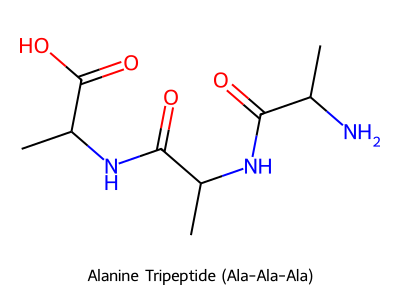

In [2]:
# ── Visualize Alanine Tripeptide ──────────────────────────────────────────────
# This code block generates and displays the 2D structure of an Alanine Tripeptide.

# Define the SMILES string for Alanine tripeptide (Ala-Ala-Ala).
# This represents a linear chain of three alanine residues linked by peptide bonds.
# Note: This SMILES is a simplified representation and does not include stereochemistry.
alanine_tripeptide_smi = "NC(C)C(=O)NC(C)C(=O)NC(C)C(=O)O"

# Convert the SMILES string into an RDKit molecule object.
ala_tripeptide_mol = Chem.MolFromSmiles(alanine_tripeptide_smi)

# Prepare lists for MolsToGridImage, even for a single molecule, to align with the
# structure of the reference cell (43527dd0).
mols_to_draw = []
labels_to_draw = []

if ala_tripeptide_mol:
    print(f"Successfully parsed SMILES for Alanine Tripeptide: {alanine_tripeptide_smi}")
    mols_to_draw.append(ala_tripeptide_mol)
    labels_to_draw.append("Alanine Tripeptide (Ala-Ala-Ala)") # Label for the displayed molecule
else:
    print(f"  Warning: Invalid SMILES for Alanine Tripeptide: {alanine_tripeptide_smi}. Cannot display 2D structure.")

# Generate a grid image of the 2D molecular structure.
# Even for a single molecule, MolsToGridImage can be used.
img_ala_tri = Draw.MolsToGridImage(
    mols_to_draw,
    molsPerRow=1,           # Display one molecule per row
    subImgSize=(400, 300),  # Specify the size of each individual molecule image
    legends=labels_to_draw  # Use the defined label
)

# Display the generated grid image.
display(img_ala_tri)

**Checkpoint:** Can you identify which structures match the SMILES strings from Section 3b?
Look for the functional groups you recognized earlier.

---

# 6. Building a 3D Molecular Model

Going from a flat SMILES string to a 3D structure requires two steps:

1. **Embedding** — placing atoms in 3D space using distance geometry (ETKDGv3 algorithm).
2. **Optimization** — minimizing the energy with a force field (MMFF94) so bond lengths,
   angles, and torsions are chemically reasonable.

We then color atoms using the standard **CPK color scheme** (named after Corey, Pauling,
and Koltun), which you may have seen on physical molecular models:

| Element | Color |
|---|---|
| H | White |
| C | Grey |
| N | Blue |
| O | Red |
| S | Yellow |
| P | Orange |
| F | Teal |
| Cl | Green |

Run the cell, then use your mouse to **rotate, zoom, and pan** the 3D model.

In [ ]:
#@title Choose your molecule
# This variable allows you to select a molecule from the `molecule_library`
# defined earlier (Section 5) or directly input a SMILES string.
# Change the value to the name of the molecule you wish to analyze (e.g., "butane", "ethanol").
molecule_choice = "butadiene"   # ← change to the name of the molecule you would like (only molecules that are in molecule_library)

In [ ]:
#@title Create a 3D viewer of the molecule
# This cell generates and displays an interactive 3D model of the selected molecule.

# ── CPK color scheme ──────────────────────────────────────────────────────────
# Define standard CPK (Corey, Pauling, Kultun) colors for different elements.
# These colors help visually distinguish atoms in the 3D model.
element_colors = {
    "H":  "#FFFFFF", # White (Hydrogen)
    "C":  "#909090", # Grey (Carbon)
    "N":  "#2944cf", # Blue (Nitrogen)
    "O":  "#d60d0d", # Red (Oxygen)
    "F":  "#37c4a9", # Teal/Green (Fluorine)
    "Cl": "#41bf41", # Green (Chlorine)
    "P":  "#FF8000", # Orange (Phosphorus)
    "S":  "#b5b50d", # Yellow (Sulfur)
}

# ── Build 3D model ────────────────────────────────────────────────────────────
# Retrieve the SMILES string for the chosen molecule from the library.
# If 'molecule_choice' is not a key in the library, it assumes 'molecule_choice' itself is a SMILES string.
smiles_input = molecule_library.get(molecule_choice, molecule_choice)

# Convert the SMILES string into an RDKit molecule object.
mol = Chem.MolFromSmiles(smiles_input)

# If SMILES parsing fails, raise an error to inform the user.
if mol is None:
    raise ValueError(f"Could not parse SMILES: '{smiles_input}'. Check the string for typos.")

# Add explicit hydrogen atoms to the molecule. This is crucial for accurate 3D geometry
# and force field calculations, as RDKit's SMILES parsing often implies hydrogens.
mol = Chem.AddHs(mol)

# Initialize parameters for the ETKDGv3 (Experimental-Torsion-Knowledge Distance Geometry) algorithm.
# This algorithm generates an initial 3D conformation (embedding).
params = AllChem.ETKDGv3()
params.randomSeed = 42           # Set a fixed random seed for reproducibility of the 3D structure.

# Generate an initial 3D conformation for the molecule.
AllChem.EmbedMolecule(mol, params)
# Optimize the 3D geometry using the MMFF94 force field.
# This minimizes the molecule's energy, resulting in a more chemically reasonable structure.
AllChem.MMFFOptimizeMolecule(mol)

# The following commented-out code block was part of an attempt to manually set dihedral angles.
# It's not strictly necessary for simple 3D display and contains a logical error for general cases.
# carbon_idxs = [a.GetIdx() for a in mol.GetAtoms() if a.GetSymbol() == 'C']
# conf = mol.GetConformer()
# # The following loop attempts to set dihedral angles for all possible carbon chains
# # but incorrectly assumes consecutive carbons in `carbon_idxs` are bonded, causing a ValueError.
# # It's also not necessary for simply displaying the 3D model, as the molecule is already embedded and optimized.
# # for i in range(len(carbon_idxs) - 3):
# #     rdMolTransforms.SetDihedralDeg(conf, carbon_idxs[i], carbon_idxs[i+1], carbon_idxs[i+2], carbon_idxs[i+3], 180.0)
# #     # Get the dihedral angle after setting it, to define 'deg'
# #     deg = rdMolTransforms.GetDihedralDeg(conf, carbon_idxs[i], carbon_idxs[i+1], carbon_idxs[i+2], carbon_idxs[i+3])
# #     # print(f"Dihedral C{i+1}-C{i+2}-C{i+3}-C{i+4}: {deg:.1f}°")

# Print basic information about the generated molecule.
print(f"Molecule: {molecule_choice}")
print(f"SMILES: {smiles_input}")
print(f"Atoms (with H): {mol.GetNumAtoms()}")
print(f"Bonds: {mol.GetNumBonds()}")

# ── Render in 3D ──────────────────────────────────────────────────────────────

# Create a py3Dmol viewer object with specified dimensions.
view = py3Dmol.view(width=600, height=400)
view.setBackgroundColor("white") # Set the background color of the viewer.

# Add the RDKit molecule's structure (in MOL block format) to the py3Dmol viewer.
view.addModel(Chem.MolToMolBlock(mol), "mol")

# Apply styling to the atoms based on their element and the CPK color scheme.
# 'stick' style creates bonds, 'sphere' style creates atoms.
for elem, color in element_colors.items():
    view.setStyle({"elem": elem}, {
        "stick": {"color": color, "radius": 0.1}, # Style for bonds (sticks)
        "sphere": {"scale": 0.25, "color": color} # Style for atoms (spheres)
    })

# Add non-hydrogen atom indexes as labels to the 3D model.
# This helps in identifying specific atoms for defining dihedral angles later.
conf = mol.GetConformer(0) # Get the first (and usually only) conformation of the molecule.
for atom in mol.GetAtoms():
    if atom.GetSymbol() != 'H':  # Exclude hydrogen atoms from labeling to avoid clutter.
        idx = atom.GetIdx()      # Get the atom's index (0-based).
        pos = conf.GetAtomPosition(idx) # Get the 3D coordinates of the atom.
        view.addLabel(str(idx + 1), { # Add a label (atom index + 1 for user-friendliness)
            "position": {"x": pos.x, "y": pos.y + 0.5, "z": pos.z}, # Position of the label
            "fontColor": "black",      # Color of the label text
            "backgroundColor": "white", # Background color for the label
            "fontSize": 12,            # Font size of the label
            "backgroundOpacity": 0.8   # Opacity of the label background
        })

view.zoomTo() # Adjust the view to show the entire molecule.
view.zoom(2)  # Zoom in a bit for better visibility.
view.show()   # Display the interactive 3D viewer.

**Explore the model:** Can you identify every atom by its color? Can you count the hydrogens?
How does the 3D structure compare to the 2D skeletal formula?

---

# 7. Conformational Energy Scanner

Now we'll rotate around the central C–C bond of our molecule and record the MMFF94 energy
at every dihedral angle from 0° to 360°. This produces the **rotational energy profile**.

The scanner:
1. Identifies the best central rotatable C–C bond automatically.
2. Sets the dihedral to each angle (every 1°, so 361 points total).
3. Minimizes the rest of the molecule lightly while holding the dihedral atoms fixed.
4. Records the energy in kJ/mol relative to the global minimum.



In [ ]:
#@title Energy Calculations
# This cell performs a conformational energy scan, rotating a specific bond
# and calculating the molecule's energy at each dihedral angle.

# Set the backend for matplotlib to 'widget' to enable interactive plots.
# This works with ipympl installed earlier.
%matplotlib widget

# ── 7a. Find the dihedral atoms ───────────────────────────────────────────────

def get_rotation_atoms(mol):
    """
    Finds a central rotatable C–C single bond in the molecule.
    It returns the indices of four atoms (a, b, c, d) that define the dihedral
    angle a–b–c–d. The bond b-c is the central rotating bond.
    The function aims to pick the 'middle-most' rotatable C-C bond to represent
    the overall conformational changes in longer chains.
    """
    rot_bonds = [] # List to store indices of atoms forming rotatable C-C single bonds
    for bond in mol.GetBonds(): # Iterate through all bonds in the molecule
        a1 = bond.GetBeginAtom() # Get the first atom of the bond
        a2 = bond.GetEndAtom()   # Get the second atom of the bond
        # Check if the bond is a single bond (bond type 1.0),
        # not part of a ring (to ensure free rotation),
        # and both atoms are carbons.
        if (bond.GetBondTypeAsDouble() == 1.0
                and not bond.IsInRing()
                and a1.GetSymbol() == 'C'
                and a2.GetSymbol() == 'C'):
            rot_bonds.append((a1.GetIdx(), a2.GetIdx())) # Store indices of the bonded atoms

    # If no rotatable C-C bonds are found, raise an error.
    if not rot_bonds:
        raise ValueError("No rotatable C–C bonds found in this molecule. "
                         "Try butane, pentane, or another acyclic alkane.")

    # Select the central rotatable bond. This heuristic attempts to pick a bond
    # that is most representative for observing conformational changes.
    b_idx, e_idx = rot_bonds[len(rot_bonds) // 2] # Select the middle bond from the list

    # Helper function to find the 'best' neighbor for defining the dihedral.
    # It prioritizes carbon neighbors, then any other neighbor.
    def best_neighbor(atom_idx, exclude_idx):
        # Get all neighbors of the atom_idx, excluding the atom on the other side of the central bond.
        neighbors = [n for n in mol.GetAtomWithIdx(atom_idx).GetNeighbors()
                     if n.GetIdx() != exclude_idx]
        # Filter for carbon neighbors.
        carbons = [n for n in neighbors if n.GetSymbol() == 'C']
        # If carbon neighbors exist, return the first one; otherwise, return the first available neighbor.
        return (carbons[0] if carbons else neighbors[0]).GetIdx()

    # Find the 'a' atom (connected to b_idx but not e_idx) and 'd' atom (connected to e_idx but not b_idx).
    # These four atoms (a, b_idx, e_idx, d) define the dihedral angle.
    a = best_neighbor(b_idx, e_idx)
    d = best_neighbor(e_idx, b_idx)
    return a, b_idx, e_idx, d

# Get the four atom indices that define the central dihedral angle for rotation.
atom_a, atom_b, atom_c, atom_d = get_rotation_atoms(mol)
print(f"Central bond selected: C{atom_b}–C{atom_c}")
print(f"Dihedral atoms: "
      f"{mol.GetAtomWithIdx(atom_a).GetSymbol()}{atom_a}–"
      f"C{atom_b}–C{atom_c}–"
      f"{mol.GetAtomWithIdx(atom_d).GetSymbol()}{atom_d}")

# Initialize MMFF (Merck Molecular Force Field) properties for the molecule.
# This is needed for calculating molecular mechanics energies.
mmff_props = AllChem.MMFFGetMoleculeProperties(mol, mmffVariant="MMFF94")

# ── 7b. Scan all dihedral angles ──────────────────────────────────────────────
# For each angle, we temporarily fix the four dihedral atoms in place, then
# minimize the rest of the molecule. This isolates the torsional energy
# contribution from the bond we're rotating.

print("\nComputing energy profile...")

angles   = np.arange(0, 361, 1) # Generate angles from 0 to 360 degrees in 1-degree increments.
energies = []                   # List to store energy values for each angle.

# Loop through each angle to perform the conformational scan.
for angle in angles:
    mol_tmp = Chem.Mol(mol) # Create a temporary copy of the molecule.
                            # This is crucial to avoid modifying the original 'mol' object repeatedly.
    # Set the dihedral angle of the temporary molecule to the current 'angle'.
    # This forces the four defined atoms (atom_a, atom_b, atom_c, atom_d) into the specified orientation.
    rdMolTransforms.SetDihedralDeg(
        mol_tmp.GetConformer(), atom_a, atom_b, atom_c, atom_d, float(angle)
    )
    # Create a force field object for the temporary molecule.
    ff = AllChem.MMFFGetMoleculeForceField(mol_tmp, mmff_props)
    # Add position constraints to the four atoms defining the dihedral angle.
    # This prevents these atoms from moving during minimization, ensuring that
    # only other parts of the molecule adjust to relieve strain while the dihedral is fixed.
    for atom_idx in [atom_a, atom_b, atom_c, atom_d]:
        ff.MMFFAddPositionConstraint(atom_idx, 0, 1e4) # The '1e4' is a large force constant, effectively fixing position.
    ff.Minimize(maxIts=500) # Minimize the energy of the molecule (excluding the fixed dihedral atoms).
    # Calculate the energy using the force field and convert from kcal/mol (default) to kJ/mol.
    # (1 kcal = 4.184 kJ)
    energies.append(ff.CalcEnergy() * 4.184)

energies          = np.array(energies) # Convert the list of energies to a NumPy array for easier calculations.
min_absolute_energy = energies.min()     # Find the minimum energy value in the entire scan.
# Normalize energies so the lowest energy conformation is set to 0 kJ/mol.
# This makes it easier to compare relative stabilities.
energies          = energies - min_absolute_energy

min_energy    = energies.min() # The new minimum, which will be 0.
max_energy    = energies.max() # The highest energy relative to the minimum.
barrier_height = max_energy - min_energy # Calculate the rotational barrier height.

print(f"\nDone!")
# Print key results from the energy scan.
print(f"  Barrier height (ΔE): {barrier_height:.2f} kJ/mol")
# Find the angle corresponding to the most stable (lowest energy) conformation.
print(f"  Most stable conformation: {angles[np.argmin(energies)]}°")
# Find the angle corresponding to the least stable (highest energy) conformation.
print(f"  Least stable conformation: {angles[np.argmax(energies)]}°")

---

# 8. Interactive Visualization

The widget below combines the 3D molecular viewer and the energy profile plot.
Drag the **Dihedral Angle** slider to rotate around the central C–C bond and watch:
- The 3D model update in real time
- The orange dot trace the energy curve

**What to look for:**
- Where are the minima? Are they all the same depth (symmetric molecule) or different (asymmetric)?
- Where are the maxima? What does the 3D structure look like at those points?
- How large is the rotational barrier compared to thermal energy at room temperature
  (~2.5 kJ/mol)? Can the molecule rotate freely?

In [ ]:
#@title Conformational Energy Scanner
# This cell creates an interactive widget that combines the 3D molecular viewer
# with the energy profile plot. Users can drag a slider to change the dihedral angle
# and see the molecule's conformation and corresponding energy update in real-time.

# ── 1. Molecule setup ─────────────────────────────────────────────────────────

# This is a slightly modified version of get_rotation_atoms, allowing user input
# for specific bond selection.
def get_rotation_atoms(mol, b_idx_user=None, c_idx_user=None):
    # If the user provides specific atom indices (1-based), adjust to 0-based and validate.
    if b_idx_user is not None and c_idx_user is not None:
        atom_b = b_idx_user
        atom_c = c_idx_user
        # Verify if the chosen atoms form a bond, are carbons, and not in a ring.
        bond = mol.GetBondBetweenAtoms(atom_b, atom_c);
        if bond is None or mol.GetAtomWithIdx(atom_b).GetSymbol() != 'C' or mol.GetAtomWithIdx(atom_c).GetSymbol() != 'C':
            raise ValueError(f"Atoms {atom_b+1} and {atom_c+1} do not form a C-C bond or are not both carbons.")
        if bond.IsInRing():
            raise ValueError(f"The bond between C{atom_b+1} and C{atom_c+1} is in a ring. Rotating it will distort the molecule.")
    else:
        # If no specific bond is provided by the user, automatically find a central C-C rotatable bond.
        rot_bonds = []
        for bond in mol.GetBonds():
            a1 = bond.GetBeginAtom()
            a2 = bond.GetEndAtom()
            if (bond.GetBondTypeAsDouble() == 1.0
                    and not bond.IsInRing()
                    and a1.GetSymbol() == 'C'
                    and a2.GetSymbol() == 'C'):
                rot_bonds.append((a1.GetIdx(), a2.GetIdx()))

        if not rot_bonds:
            raise ValueError("No rotatable C-C bonds found.")
        # Select the 'middle-most' rotatable bond.
        atom_b, atom_c = rot_bonds[len(rot_bonds) // 2]

    # Helper function to find the 'best' neighbor for defining the dihedral angle, prioritizing carbons.
    def best_neighbor(atom_idx, exclude_idx):
        neighbors = [n for n in mol.GetAtomWithIdx(atom_idx).GetNeighbors()
                     if n.GetIdx() != exclude_idx]
        carbons = [n for n in neighbors if n.GetSymbol() == 'C']
        if carbons:
            return carbons[0].GetIdx()
        elif neighbors:
            return neighbors[0].GetIdx()
        else:
            # If no neighbors (shouldn't happen for a bonded atom), return itself or handle error.
            return atom_idx

    # Determine the four atoms (a, b, c, d) that define the dihedral angle to be rotated.
    atom_a = best_neighbor(atom_b, atom_c)
    atom_d = best_neighbor(atom_c, atom_b)
    return atom_a, atom_b, atom_c, atom_d

# Main function to run the conformational scan and set up the interactive display.
def run_conformational_scan(b_idx_user=None, c_idx_user=None):
    # Notice: No global variables. Everything is safely enclosed per-run.
    initial_angle = 0 # Starting dihedral angle for the display.

    try:
        # Adjust user-provided atom indices from 1-based to 0-based for RDKit.
        adjusted_b_idx = b_idx_user - 1 if b_idx_user is not None else None
        adjusted_c_idx = c_idx_user - 1 if c_idx_user is not None else None
        # Get the four atoms defining the dihedral angle.
        atom_a, atom_b, atom_c, atom_d = get_rotation_atoms(mol, adjusted_b_idx, adjusted_c_idx)
    except ValueError as e:
        # If bond selection fails, print an error and return a widget with the error message.
        print(f"Error selecting bond: {e}")
        return widgets.Label(value=f"Error: {e}")

    # Print the selected rotating bond and dihedral atoms for confirmation.
    print(f"Rotating bond: C{atom_b}–C{atom_c}")
    print(f"Dihedral: {mol.GetAtomWithIdx(atom_a).GetSymbol()}{atom_a} – "
          f"C{atom_b} – C{atom_c} – "
          f"{mol.GetAtomWithIdx(atom_d).GetSymbol()}{atom_d}")

    # Initialize MMFF properties for energy calculations.
    mmff_props = AllChem.MMFFGetMoleculeProperties(mol, mmffVariant="MMFF94")

    # Prepare the initial 3D display of the molecule.
    mol_initial_display = Chem.Mol(mol) # Create a copy of the molecule for the initial view.
    # Set the dihedral angle to the initial angle (0 degrees).
    rdMolTransforms.SetDihedralDeg(mol_initial_display.GetConformer(), atom_a, atom_b, atom_c, atom_d, float(initial_angle))
    # Create a force field and apply position constraints to the dihedral atoms
    # to keep them fixed during a light minimization for display purposes.
    ff_initial = AllChem.MMFFGetMoleculeForceField(mol_initial_display, mmff_props)
    ff_initial.MMFFAddPositionConstraint(atom_a, 0, 1e4)
    ff_initial.MMFFAddPositionConstraint(atom_b, 0, 1e4)
    ff_initial.MMFFAddPositionConstraint(atom_c, 0, 1e4)
    ff_initial.MMFFAddPositionConstraint(atom_d, 0, 1e4)
    ff_initial.Minimize(maxIts=500)

    # Setup py3Dmol viewer for interactive molecule display.
    view = py3Dmol.view(width=700, height=420)
    view.setBackgroundColor("white")
    view.removeAllModels()
    view.addModel(Chem.MolToMolBlock(mol_initial_display), "mol")
    # Apply CPK coloring and styling for atoms and bonds.
    for e, c in element_colors.items():
        view.setStyle({"elem": e}, {"stick": {"color": c, "radius": 0.1}, "sphere": {"scale": 0.25, "color": c}})

    rotating_bond_color = "#FFFF00" # Define a special color for the rotating bond (yellow).

    # Highlight the atoms forming the rotating bond (atom_b and atom_c) in the special color.
    view.setStyle({"index": atom_b}, {
        "stick": {"color": rotating_bond_color, "radius": 0.1},
        "sphere": {"scale": 0.25, "color": rotating_bond_color}
    })
    view.setStyle({"index": atom_c}, {
        "stick": {"color": rotating_bond_color, "radius": 0.1},
        "sphere": {"scale": 0.25, "color": rotating_bond_color}
    })

    # Add labels for non-hydrogen atoms to the 3D viewer.
    view.removeAllLabels()
    conf_initial = mol_initial_display.GetConformer(0)
    for atom in mol_initial_display.GetAtoms():
        if atom.GetSymbol() != 'H':
            idx = atom.GetIdx()
            pos = conf_initial.GetAtomPosition(idx)
            view.addLabel(str(idx + 1), {
                "position": {"x": pos.x, "y": pos.y + 0.5, "z": pos.z},
                "fontColor": "black",
                "backgroundColor": "white",
                "fontSize": 12,
                "backgroundOpacity": 0.8
            })

    # view.update() # This line is often needed in interactive updates, but not strictly for initial setup.

    # CRITICAL: Re-initialize properties to ensure clean state for energy loop, matching the old code
    # This ensures that any temporary modifications to 'mol' do not persist across runs or impact subsequent calculations.
    mmff_props = AllChem.MMFFGetMoleculeProperties(mol, mmffVariant="MMFF94")

    # ── 2. Pre-compute energies with position constraints ─────────────────────────
    # This section calculates the energy for all possible dihedral angles (0-360 degrees)
    # before the interactive widget is displayed, making the slider updates fast.
    print("Computing energies...")
    angles = np.arange(0, 361, 1) # Array of angles from 0 to 360 degrees.
    energies_list = []           # List to store calculated energies.

    for angle in angles:
        mol_tmp = Chem.Mol(mol) # Create a fresh copy of the molecule for each angle.
        # Set the dihedral angle for the current temporary molecule.
        rdMolTransforms.SetDihedralDeg(mol_tmp.GetConformer(), atom_a, atom_b, atom_c, atom_d, float(angle))
        # Initialize force field and apply position constraints to the dihedral atoms.
        ff = AllChem.MMFFGetMoleculeForceField(mol_tmp, mmff_props)
        ff.MMFFAddPositionConstraint(atom_a, 0, 1e4)
        ff.MMFFAddPositionConstraint(atom_b, 0, 1e4)
        ff.MMFFAddPositionConstraint(atom_c, 0, 1e4)
        ff.MMFFAddPositionConstraint(atom_d, 0, 1e4)
        ff.Minimize(maxIts=500) # Minimize the molecule's energy.
        energies_list.append(ff.CalcEnergy() * 4.184) # Store energy, converted to kJ/mol.

    energies = np.array(energies_list) # Convert to NumPy array.
    min_absolute_energy = energies.min() # Find the global minimum energy.
    energies = energies - min_absolute_energy # Normalize energies relative to the minimum.

    min_energy = energies.min() # Should be 0 after normalization.
    max_energy = energies.max() # Maximum relative energy.
    barrier_height = max_energy - min_energy # Calculate the energy barrier.
    print("Done!")

    # ── 3. Layout ─────────────────────────────────────────────────────────────────
    # This section sets up the display widgets for the 3D model and the energy plot.

    # Output widget for the 3D molecule viewer.
    mol_out = widgets.Output(layout=widgets.Layout(width='50%'))
    with mol_out:
        display(view)

    # Setup Matplotlib figure and axes for the energy profile plot.
    fig, ax = plt.subplots(figsize=(5.5, 4))
    fig.patch.set_facecolor('#f8f8f8') # Set figure background color.
    ax.set_facecolor('#f8f8f8')       # Set axes background color.
    ax.plot(angles, energies, color='#87cefa', linewidth=2) # Plot the energy profile.
    ax.set_xlabel('Dihedral Angle (°)', color='#333333', fontsize=10) # X-axis label.
    ax.set_ylabel('Relative Energy (kJ/mol)', color='#333333', fontsize=10) # Y-axis label.
    ax.tick_params(colors='#333333') # Tick label color.
    ax.set_xlim(-40, 450)           # X-axis limits for better visual spacing.
    ax.set_xticks([0, 60, 120, 180, 240, 300, 360]) # Custom x-axis ticks.
    ax.set_ylim(min_energy - 1, max_energy + 1) # Y-axis limits.
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc') # Color of the plot border.

    # Add a marker (dot) and a vertical line to indicate the current dihedral angle and energy on the plot.
    dot, = ax.plot([angles[initial_angle]], [energies[initial_angle]], 'o', color='#FF5722', markersize=9, zorder=5)
    vline = ax.axvline(x=angles[initial_angle], color='#FF5722', linewidth=0.8, linestyle='--', alpha=0.6)
    # Set the plot title, including the current energy value.
    title = ax.set_title(f'Conformational Energy Profile   |   {energies[initial_angle]:.4f} kJ/mol',
                         color='#333333', fontsize=11)
    plt.tight_layout() # Adjust plot to prevent labels from overlapping.

    # Add an annotation for the barrier height (ΔE) on the plot.
    ax.annotate('', xy=(380, max_energy), xytext=(380, min_energy),
                arrowprops=dict(arrowstyle='->', color='purple', lw=1.2))
    ax.plot([400, 300], [min_energy, min_energy], color='purple', linestyle='--', linewidth=1.5, zorder=4)
    ax.plot([400, 360], [max_energy, max_energy], color='purple', linestyle='--', linewidth=1.5, zorder=4)
    ax.text(388, (min_energy + max_energy) / 2, f'ΔE: {barrier_height:.2f}\nkJ/mol',
            color='purple', fontsize=9, ha='left', va='center',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

    # Output widget for the Matplotlib plot.
    plot_out = widgets.Output(layout=widgets.Layout(width='50%'))
    with plot_out:
        plt.show()

    # ── 4. Slider ─────────────────────────────────────────────────────────────────
    # Create an integer slider widget for controlling the dihedral angle.
    slider = widgets.IntSlider(initial_angle, 0, 360, 1, description="Dihedral",
                               continuous_update=True, # Update continuously as slider is dragged.
                               layout=widgets.Layout(width='98%'))

    # Define the function that updates the 3D model and plot when the slider value changes.
    def update_slider_and_view(change):
        angle = change['new'] # Get the new angle value from the slider.

        mol_tmp = Chem.Mol(mol) # Create a temporary copy of the molecule.
        # Set the dihedral angle to the new slider value.
        rdMolTransforms.SetDihedralDeg(mol_tmp.GetConformer(), atom_a, atom_b, atom_c, atom_d, float(angle))
        # Re-run force field minimization with position constraints for the new conformation.
        ff = AllChem.MMFFGetMoleculeForceField(mol_tmp, mmff_props)
        ff.MMFFAddPositionConstraint(atom_a, 0, 1e4)
        ff.MMFFAddPositionConstraint(atom_b, 0, 1e4)
        ff.MMFFAddPositionConstraint(atom_c, 0, 1e4)
        ff.MMFFAddPositionConstraint(atom_d, 0, 1e4)
        ff.Minimize(maxIts=500)
        # Calculate the relative energy for the new conformation.
        energy_rel = ff.CalcEnergy() * 4.184 - min_absolute_energy

        # Update the 3D molecular model in the py3Dmol viewer.
        view.removeAllModels() # Clear existing model.
        view.addModel(Chem.MolToMolBlock(mol_tmp), "mol") # Add the updated model.
        # Re-apply general styling.
        for e, c in element_colors.items():
            view.setStyle({"elem": e}, {"stick": {"color": c, "radius": 0.1}, "sphere": {"scale": 0.25, "color": c}})

        # Re-highlight the rotating bond.
        view.setStyle({"index": atom_b}, {
            "stick": {"color": rotating_bond_color, "radius": 0.1},
            "sphere": {"scale": 0.25, "color": rotating_bond_color}
        })
        view.setStyle({"index": atom_c}, {
            "stick": {"color": rotating_bond_color, "radius": 0.1},
            "sphere": {"scale": 0.25, "color": rotating_bond_color}
        })

        # Re-add atom labels for the updated conformation.
        view.removeAllLabels()
        conf_tmp = mol_tmp.GetConformer(0)
        for atom in mol_tmp.GetAtoms():
            if atom.GetSymbol() != 'H':
                idx = atom.GetIdx()
                pos = conf_tmp.GetAtomPosition(idx)
                view.addLabel(str(idx + 1), {
                    "position": {"x": pos.x, "y": pos.y + 0.5, "z": pos.z},
                    "fontColor": "black",
                    "backgroundColor": "white",
                    "fontSize": 12,
                    "backgroundOpacity": 0.8
                })

        view.update() # Crucial command to refresh the py3Dmol viewer.

        # Update the marker, vertical line, and title on the Matplotlib energy plot.
        dot.set_data([angle], [energies[angle]]) # Move the dot to the new angle and energy.
        vline.set_xdata([angle])                  # Move the vertical line.
        title.set_text(f'Conformational Energy Profile   |   {energy_rel:.4f} kJ/mol') # Update title with current energy.
        fig.canvas.draw_idle() # Redraw the plot to reflect changes efficiently.

    # Attach the update function to the slider's 'value' change event.
    slider.observe(update_slider_and_view, names='value')

    # Return a vertical box containing the slider and a horizontal box with the 3D viewer and plot.
    return widgets.VBox([slider, widgets.HBox([mol_out, plot_out])])


# --- User input for bond selection --- (This section provides widgets for users to manually select a bond)
# Determine default dihedral atoms to pre-populate the input fields.
default_a, default_b, default_c, default_d = get_rotation_atoms(mol)

# Create an integer text input widget for the first atom of the rotating bond (1-based index).
bond_b_input = widgets.IntText(
    value=default_b + 1, # Display 1-based index
    description='Static Atom:', # Label for the input field
    disabled=False
)
# Create an integer text input widget for the second atom of the rotating bond (1-based index).
bond_c_input = widgets.IntText(
    value=default_c + 1, # Display 1-based index
    description='Spinning Atom:', # Label for the input field
    disabled=False
)
# Create a button to trigger the conformational scan with the user-selected bond.
set_bond_button = widgets.Button(
    description='Set Rotating Bond',
    disabled=False,
    button_style='',
    tooltip='Click to set the rotating bond',
    icon='check'
)

# An Output widget to display the results of the conformational scanner (the interactive plot and 3D viewer).
conformational_scanner_output = widgets.Output()

# Define the function to execute when the 'Set Rotating Bond' button is clicked.
def on_set_bond_button_clicked(b):
    with conformational_scanner_output: # Direct output to the designated widget.
        conformational_scanner_output.clear_output(wait=True) # Clear previous output.
        # Run the scan with user-specified bond indices.
        display(run_conformational_scan(b_idx_user=bond_b_input.value, c_idx_user=bond_c_input.value))

# Attach the click event handler to the button.
set_bond_button.on_click(on_set_bond_button_clicked)

# Initial display of the conformational scanner (using the automatically selected bond).
with conformational_scanner_output:
    display(run_conformational_scan())

# Display the bond selection input fields and button, followed by the scanner output.
display(widgets.HBox([bond_b_input, bond_c_input, set_bond_button]), conformational_scanner_output)

---

# 9. Results & Interpretation

Use your energy profile and the slider to answer the following questions in the
markdown cell (or on paper). Then compare with the discussion below.

## Questions for Reflection

###**Question 1:**

*   At approximately what dihedral angles do you observe energy minima?
What type of conformation (staggered, anti, gauche) does each minimum represent?




###**Question 2:**
*   At approximately what dihedral angles do you observe energy maxima?
What type of conformation (eclipsed, fully eclipsed) does each maximum represent?

###**Question 3:**
*   Is the energy profile symmetric? Why or why not?
*(Hint: think about the symmetry of the molecule you chose.)*

###**Question 4:**
*   Is the rotational barrier small or large compared to room-temperature thermal
energy (~2.5 kJ/mol)? What does this imply about how freely the molecule rotates at 25°C?

###**Question 4:**
*   If you chose butane: what is the energy difference between the anti and gauche
conformations? This is called the **gauche penalty**. Look up a literature value —
how does your computed value compare?

---



# 10. Assessment Questions

Answer each question based on what you observed in this notebook and your course notes.

---

###**Question 1 — SMILES Interpretation**

*   Write the SMILES string for **2-methylbutane** (isopentane) without looking it up.
Check your answer by adding it to `molecule_library` in Section 3c and running
the 2D display cell. Does your 2D structure match what you expected?

*(Hint: the parent chain is butane `CCCC`; a methyl branch on C2 is added with parentheses.)*

---

###**Question 2 — Identifying Conformational Features**

*   Run the conformational scanner on **butane** (set `molecule_choice = "butane"` in Section 6).

*   (a) How many energy minima appear between 0° and 360°?
*   (b) How many energy maxima appear?
*   (c) Identify the global minimum: is it the anti or gauche conformation?

---

###**Question 3 — Comparing Molecules**

*   Run the scanner on **ethane** (`molecule_choice = "ethane"`) and then on **butane**.

*   (a) Compare the barrier heights. Which is larger? Why?
*   (b) How many minima does ethane have between 0° and 360°? How many does butane have?
*   (c) Are all minima in ethane equal in energy? Are all minima in butane equal in energy?
    Explain the difference in terms of molecular structure.
*   (d) Sketch (on paper) what a Newman projection of each minimum looks like.

---

###**Question 4 — Prediction Before Running**

*   Before running the scanner, predict the shape of the energy profile for **propane**
(`molecule_choice = "propane"`):
*   (a) How many minima do you expect? Are they equivalent?
*   (b) Estimate the barrier height: will it be closer to ethane or butane? Explain.
*   (c) Run it and compare to your prediction. Were you correct?

---

---

# 11. Wrap-Up

In this notebook you:
- Learned to **read and write SMILES** notation for organic molecules.
- Get comfortable with running multiple code cells in the correct order.
- Connected computational results to the physical chemistry concepts of **torsional strain,
  steric strain, and conformational stability**.

The same workflow scales to larger, more complex molecules — try aspirin or capsaicin from
the library, or input any molecule you find on PubChem!

---

## Challenge Extensions

1. **Write your own SMILES:** Find a molecule on PubChem, copy its SMILES, paste it into
   `molecule_library`, and run the full analysis. Does the energy profile make chemical sense?

2. **Isobutane vs. butane:** Run both and compare. Isobutane has a tertiary carbon at the
   center. Does that change the barrier or the number of minima?

3. **Heteroatom effect:** Replace one carbon in butane with nitrogen (SMILES: `CCNC`).
   How does the nitrogen change the energy profile? *(Hint: lone pair interactions.)*

4. **Energy units:** The code converts kcal/mol → kJ/mol (multiply by 4.184). Find the line
   in Section 7b where this happens and change it to keep units in kcal/mol. How does the
   plot change? What is the approximate barrier in kcal/mol for butane?

---

## Notebook Sign-Off Checklist

* [ ] **Purpose is clear** from the header without opening code cells.
* [ ] **Every significant decision** has a markdown explanation.
* [ ] **Learning goals** are listed explicitly at the start.
* [ ] **Assessment questions** are answered and submitted.
* [ ] **Variable names** indicate both content and workflow stage.
* [ ] **Kernel restarted** and all cells run top-to-bottom without error.
* [ ] **molecule_choice** was tested with at least two different molecules.